# 09 – Model Comparison, Final Test and Saving the Final Model
**IT3051 Fundamentals of Data Mining – Mini Project 2026 – PE2 (modelling)**
**Task:** Regression – predict **`Days for shipping (real)`** at order placement.
**Owner:** M3 leads the comparison (whole team)

### What this notebook does
1. Collects every member's tuned model results (from notebooks 05–08).
2. Compares them side by side with the same scores and the same folds.
3. Chooses the **final model** with M4's rules.
4. Tests **only the final model, once**, on the hidden test set.
5. Explains what drives the predictions (for the report and the presentation).
6. Saves the final model for the backend.

### How the winner is chosen (M4's rules)
1. Lowest cross-validated **MAE** (average days wrong) is best.
2. Models whose MAE is within the best model's `MAE_std` (normal fold-to-fold noise) count as a **tie**.
3. In a tie, the **simpler** model wins (easier to explain, less likely to break).
4. The winner is checked against the Shipping Mode baseline. If no model beats it, we report that honestly.

**Run after:** notebooks 05, 06, 07 and 08.
**Input:** `results/params_*.json`, `results/experiments.csv`, `train_fe.csv`, `test_fe.csv`, M3's and M4's decision files.
**Output:** `models/final_pipeline.pkl`, `models/model_info.json`, charts in `reports/figures/final/`.

## Step 0 – Setup
Same shared helpers as notebooks 04–08, plus `joblib` to save the final model.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "reports" / "figures" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TARGET, GROUP, SEED = "Days for shipping (real)", "Order Id", 42
METRICS = ["MAE", "RMSE", "R2", "MedAE", "within_1_day_%", "bias"]
SCALERS = {"none": None, "standard": StandardScaler, "robust": RobustScaler, "minmax": MinMaxScaler}

def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    err = y_pred - y_true
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2": r2_score(y_true, y_pred),
            "MedAE": median_absolute_error(y_true, y_pred),
            "within_1_day_%": float((np.abs(err) <= 1).mean() * 100),
            "bias": float(err.mean())}

def make_cv(X, y, groups, n_splits=5, seed=SEED):
    return list(StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(X, y, groups))

def cv_evaluate(pipe, X, y, cv_splits):
    rows = []
    for i, (tr, va) in enumerate(cv_splits):
        model = clone(pipe).fit(X.iloc[tr], y.iloc[tr])
        rows.append({"fold": i, **regression_metrics(y.iloc[va], model.predict(X.iloc[va]))})
    per_fold = pd.DataFrame(rows)
    summary = {m: float(per_fold[m].mean()) for m in METRICS}
    summary["MAE_std"] = float(per_fold["MAE"].std())
    return summary, per_fold

def log_experiment(row, path=RESULTS_DIR / "experiments.csv"):
    new = pd.DataFrame([row])
    out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new
    out.to_csv(path, index=False)

def build_preprocessor(plan):
    parts = []
    if plan["numeric"]:
        parts.append(("num", SimpleImputer(strategy="median"), plan["numeric"]))
    if plan["onehot"]:
        parts.append(("onehot", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                          ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), plan["onehot"]))
    if plan["onehot_rare"]:
        parts.append(("onehot_rare", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist",
                                                   sparse_output=False), plan["onehot_rare"]))
    if plan["target"]:
        parts.append(("target", TargetEncoder(target_type="continuous", random_state=SEED), plan["target"]))
    return ColumnTransformer(parts, remainder="drop")

def build_full_pipeline(model, plan, scaler="none"):
    steps = [("prep", build_preprocessor(plan))]
    if SCALERS[scaler] is not None:
        steps.append(("scale", SCALERS[scaler]()))
    steps.append(("model", model))
    return Pipeline(steps)

import joblib
from sklearn.inspection import permutation_importance

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_FIG = ROOT / "reports" / "figures" / "final"
FINAL_FIG.mkdir(parents=True, exist_ok=True)
DATE_COL, DATE_FMT = "order date (DateOrders)", "%m/%d/%Y %H:%M"

## Step 1 – Collect every member's results
Each model notebook saved `results/params_<model>.json` with its best settings and cross-validated scores.

In [2]:
m3 = json.loads((RESULTS_DIR / "m3_selection.json").read_text(encoding="utf-8"))
m4 = json.loads((RESULTS_DIR / "m4_preprocessing.json").read_text(encoding="utf-8"))
FEATURES, PLAN, CATEGORY_COL = m3["features"], m3["plan"], m3["category_column"]
MODE_BASELINE_MAE = m4["reference_cv_MAE"]["Baseline: mean per Shipping Mode"]

params = {}
for p in sorted(RESULTS_DIR.glob("params_*.json")):
    info = json.loads(p.read_text(encoding="utf-8"))
    params[info["model"]] = info
print("Models found:", list(params))
missing = {"Ridge", "RandomForest", "XGBoost", "DecisionTree", "KNN"} - set(params)
if missing:
    print("Not run yet:", missing)

board = pd.DataFrame({
    name: {"owner": i["owner"], "scaler": i["scaler"], "default_MAE": i["cv_MAE_default"],
           **i["cv_scores_tuned"], "MAE_std": i["cv_MAE_std"]}
    for name, i in params.items()
}).T
board = board.astype({c: float for c in board.columns if c not in ("owner", "scaler")}).sort_values("MAE")
board["beats_baseline"] = board["MAE"] < MODE_BASELINE_MAE
print(f"Shipping Mode baseline MAE: {MODE_BASELINE_MAE}")
board.round(4)

Models found: ['DecisionTree', 'KNN', 'RandomForest', 'Ridge', 'XGBoost']
Shipping Mode baseline MAE: 0.9867


,owner,scaler,default_MAE,MAE,RMSE,R2,MedAE,within_1_day_%,bias,MAE_std,beats_baseline
DecisionTree,M4,none,1.3108,0.9617,1.2666,0.3930,0.9897,52.1970,-0.0000,0.0103,True
RandomForest,M2,none,0.9997,0.9650,1.2684,0.3914,0.9951,52.0638,-0.0002,0.0103,True
XGBoost,M3,none,1.0027,0.9692,1.2678,0.3919,0.9942,51.9912,-0.0005,0.0100,True
Ridge,M1,minmax,0.9959,0.9933,1.2712,0.3886,0.9937,51.9830,0.0001,0.0088,False
KNN,M4,minmax,1.0383,1.0091,1.2962,0.3644,0.9640,52.2061,0.0005,0.0094,False


## Step 2 – Compare the models visually
Bars show the tuned cross-validated MAE; the thin lines are the fold-to-fold noise (`MAE_std`). The dashed line is the baseline.
Bars whose error lines overlap are not really different.

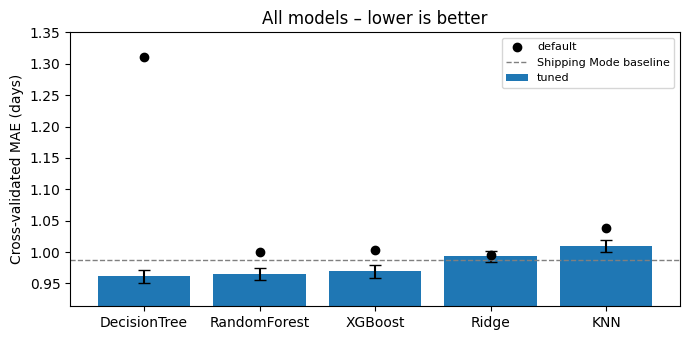

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(board.index, board["MAE"], yerr=board["MAE_std"], capsize=4, label="tuned")
ax.scatter(board.index, board["default_MAE"], color="black", zorder=3, label="default")
ax.axhline(MODE_BASELINE_MAE, color="grey", ls="--", lw=1, label="Shipping Mode baseline")
ax.set_ylabel("Cross-validated MAE (days)"); ax.set_title("All models – lower is better")
ax.set_ylim(min(board["MAE"].min(), MODE_BASELINE_MAE) * 0.95, max(board["default_MAE"].max(), MODE_BASELINE_MAE) * 1.03)
ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(FINAL_FIG / "01_model_comparison.png", dpi=120); plt.show()

## Step 3 – Choose the final model
Apply the rules: find the best MAE, collect every model within its noise level (a tie), then pick the simplest of those.
Simplicity order used: Ridge → Decision Tree → KNN → Random Forest → XGBoost.

In [4]:
SIMPLICITY = ["Ridge", "DecisionTree", "KNN", "RandomForest", "XGBoost"]
best_name = board.index[0]
threshold = board.loc[best_name, "MAE"] + board.loc[best_name, "MAE_std"]
tied = board[board["MAE"] <= threshold].index.tolist()
WINNER = min(tied, key=SIMPLICITY.index)

print(f"Lowest MAE: {best_name} ({board.loc[best_name, 'MAE']:.4f} ± {board.loc[best_name, 'MAE_std']:.4f})")
print(f"Tie zone (MAE <= {threshold:.4f}): {tied}")
print(f"FINAL MODEL: {WINNER}")
if WINNER != best_name:
    print(f"-> {WINNER} is within the noise of {best_name} and is simpler, so it is chosen.")
if board.loc[WINNER, "MAE"] < MODE_BASELINE_MAE:
    print(f"{WINNER} beats the Shipping Mode baseline ({MODE_BASELINE_MAE}).")
else:
    print(f"Note: {WINNER} does NOT beat the Shipping Mode baseline ({MODE_BASELINE_MAE}). Report this honestly: "
          "the order-time features add little beyond shipping mode.")

Lowest MAE: DecisionTree (0.9617 ± 0.0103)
Tie zone (MAE <= 0.9720): ['DecisionTree', 'RandomForest', 'XGBoost']
FINAL MODEL: DecisionTree
DecisionTree beats the Shipping Mode baseline (0.9867).


## Step 4 – Rebuild the final model and the baseline
The final model is rebuilt with its best settings and trained on the **whole training set**.
The Shipping Mode baseline is trained the same way, so both can be compared fairly on the test set.

In [5]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

def make_model(name):
    if name == "Ridge":
        return Ridge()
    if name == "RandomForest":
        return RandomForestRegressor(max_samples=0.5, n_jobs=-1, random_state=SEED)
    if name == "XGBoost":
        from xgboost import XGBRegressor
        return XGBRegressor(tree_method="hist", n_jobs=-1, random_state=SEED)
    if name == "DecisionTree":
        return DecisionTreeRegressor(random_state=SEED)
    if name == "KNN":
        return KNeighborsRegressor(n_jobs=-1)
    raise ValueError(name)

info = params[WINNER]
final_model = make_model(WINNER).set_params(**info["best_params"])
final_pipe = build_full_pipeline(final_model, PLAN, info["scaler"])

mode_plan = {"numeric": [], "onehot": ["Shipping Mode"], "onehot_rare": [], "target": []}
baseline_pipe = build_full_pipeline(Ridge(alpha=1.0), mode_plan, "standard")

train = pd.read_csv(PROCESSED_DIR / "train_fe.csv")
test = pd.read_csv(PROCESSED_DIR / "test_fe.csv")
if CATEGORY_COL == "Category Id":
    train[CATEGORY_COL] = train[CATEGORY_COL].astype(str)
    test[CATEGORY_COL] = test[CATEGORY_COL].astype(str)
X_tr, y_tr = train[FEATURES], train[TARGET]
X_te, y_te = test[FEATURES], test[TARGET]

final_pipe.fit(X_tr, y_tr)
baseline_pipe.fit(X_tr, y_tr)
print(f"Trained {WINNER} with {info['best_params']} on {len(X_tr):,} rows")

Trained DecisionTree with {'min_samples_split': 2, 'min_samples_leaf': 50, 'max_depth': 3} on 138,098 rows


## Step 5 – The final test (only once)
This is the **first and only time** the test set is used for scoring. If the test MAE is close to the cross-validated MAE,
the model generalises well to new orders; a much worse test score would suggest overfitting.

In [6]:
pred_te = final_pipe.predict(X_te)
base_te = baseline_pipe.predict(X_te)
test_scores = regression_metrics(y_te, pred_te)
base_scores = regression_metrics(y_te, base_te)

final_table = pd.DataFrame({
    f"{WINNER} – cross-validation": {m: info["cv_scores_tuned"][m] for m in METRICS},
    f"{WINNER} – TEST": test_scores,
    "Shipping Mode baseline – TEST": base_scores,
})
print(f"Test set: {len(X_te):,} rows, {test[GROUP].nunique():,} orders")
final_table.round(4)

Test set: 34,667 rows, 12,579 orders


,DecisionTree – cross-validation,DecisionTree – TEST,Shipping Mode baseline – TEST
MAE,0.9617,0.9366,0.9633
RMSE,1.2666,1.2482,1.2531
R2,0.3930,0.4017,0.3970
MedAE,0.9897,0.9998,0.9972
within_1_day_%,52.1970,53.6014,53.6014
bias,-0.0000,0.0047,0.0066


## Step 6 – Understand the errors
### 6.1 Error distribution on the test set

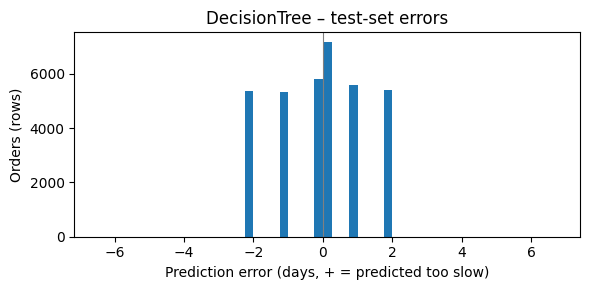

In [7]:
err = pred_te - y_te.to_numpy()
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(err, bins=np.arange(-6.5, 7, 0.25))
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Prediction error (days, + = predicted too slow)"); ax.set_ylabel("Orders (rows)")
ax.set_title(f"{WINNER} – test-set errors")
plt.tight_layout(); fig.savefig(FINAL_FIG / "02_test_errors.png", dpi=120); plt.show()

### 6.2 Average predicted vs actual days
If the model were perfect, the dots would lie on the diagonal line.

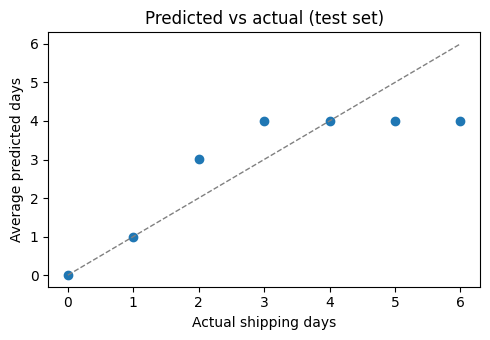

,mean,count
actual,,
0,0.00,1024
1,1.00,838
2,3.01,10705
3,3.99,5585
4,3.99,5823
5,3.99,5318
6,3.99,5374


In [8]:
pa = pd.DataFrame({"actual": y_te.to_numpy(), "predicted": pred_te}).groupby("actual")["predicted"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot([0, 6], [0, 6], color="grey", ls="--", lw=1)
ax.scatter(pa.index, pa["mean"])
ax.set_xlabel("Actual shipping days"); ax.set_ylabel("Average predicted days"); ax.set_title("Predicted vs actual (test set)")
plt.tight_layout(); fig.savefig(FINAL_FIG / "03_predicted_vs_actual.png", dpi=120); plt.show()
pa.round(2)

## Step 8 – Save the final model for the backend
- `models/final_pipeline.pkl` – the complete pipeline (encoding + scaling + model), trained on the full training set.
  It uses only scikit-learn / XGBoost parts, so the backend can load it with `joblib.load` (same library versions).
- `models/model_info.json` – everything the backend and frontend need: the features, how to make the date features,
  the allowed dropdown values, the quantity range, and the scores.

In [11]:
import sklearn
joblib.dump(final_pipe, MODELS_DIR / "final_pipeline.pkl")

categorical = [f for f in FEATURES if not pd.api.types.is_numeric_dtype(X_tr[f])]
date_features = m3.get("date_features", [])
model_info = {
    "model": WINNER,
    "best_params": info["best_params"],
    "scaler": info["scaler"],
    "target": TARGET,
    "features": FEATURES,
    "input_fields": [f for f in FEATURES if f not in date_features] + [DATE_COL],
    "date_column": DATE_COL,
    "date_format": DATE_FMT,
    "date_features": date_features,
    "allowed_values": {f: sorted(X_tr[f].astype(str).unique().tolist()) for f in categorical},
    "quantity_range": [int(X_tr["Order Item Quantity"].min()), int(X_tr["Order Item Quantity"].max())]
                      if "Order Item Quantity" in FEATURES else None,
    "cv_scores": info["cv_scores_tuned"],
    "test_scores": {m: round(v, 4) for m, v in test_scores.items()},
    "baseline_test_MAE": round(base_scores["MAE"], 4),
    "versions": {"scikit-learn": sklearn.__version__, "pandas": pd.__version__},
}
(MODELS_DIR / "model_info.json").write_text(json.dumps(model_info, indent=2, ensure_ascii=False), encoding="utf-8")

log_experiment({"owner": "Team", "experiment": "FINAL_test", "model": WINNER, "n_features": len(FEATURES),
                **{m: test_scores[m] for m in METRICS}, "MAE_std": None})

# Check: the saved file loads and gives the same predictions
reloaded = joblib.load(MODELS_DIR / "final_pipeline.pkl")
print("Saved final_pipeline.pkl and model_info.json | reload check:",
      np.allclose(reloaded.predict(X_te.head(100)), pred_te[:100]))

Saved final_pipeline.pkl and model_info.json | reload check: True


/var/folders/mk/y1xy19sx5s3bv2w4z09s03100000gn/T/ipykernel_23718/4152711301.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new


## Step 9 – Final summary (for the report, slides and viva)

In [12]:
top = importance.sort_values(ascending=False)
print(f"""
FINAL MODEL      {WINNER} (owner {info['owner']}) with {info['best_params']}
WHY CHOSEN       lowest CV MAE, or within its noise and simpler | beats baseline: {board.loc[WINNER, 'MAE'] < MODE_BASELINE_MAE}
CV MAE           {info['cv_scores_tuned']['MAE']:.4f} ± {info['cv_MAE_std']:.4f}
TEST MAE         {test_scores['MAE']:.4f}   (baseline {base_scores['MAE']:.4f})
TEST R2          {test_scores['R2']:.3f} | within 1 day {test_scores['within_1_day_%']:.1f}% | bias {test_scores['bias']:+.3f}
TOP DRIVERS      {", ".join(top.index[:3])}
SAVED            models/final_pipeline.pkl, models/model_info.json
""")


FINAL MODEL      DecisionTree (owner M4) with {'min_samples_split': 2, 'min_samples_leaf': 50, 'max_depth': 3}
WHY CHOSEN       lowest CV MAE, or within its noise and simpler | beats baseline: True
CV MAE           0.9617 ± 0.0103
TEST MAE         0.9366   (baseline 0.9633)
TEST R2          0.402 | within 1 day 53.6% | bias +0.005
TOP DRIVERS      Shipping Mode, order_hour, Order Country
SAVED            models/final_pipeline.pkl, models/model_info.json



**In plain words for the presentation:** "On orders it had never seen, the model is off by about *[test MAE]* days on average, and
gets *[within 1 day %]* of orders within one day. Shipping mode is the biggest driver of shipping time."